# Riemannian Geometry and LLMs for Learners Returning to Math

This notebook is for beginners who are interested in machine learning but feel rusty when words like `vector`, `embedding`, `tensor`, and `Riemannian geometry` start appearing in the same paragraph.

The goal is simple.

**We want to separate what an LLM actually computes from how geometry helps us interpret the learned embedding space.**

We will follow three rules.
- Start from familiar ideas: coordinates and Euclidean distance.
- Use only a small amount of math notation.
- Use code cells as intuition builders, not as formal proofs.

In [1]:
import sys
import importlib

required = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}

missing = []
for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        missing.append(package_name)

print(f"Python version: {sys.version.split()[0]}")
if missing:
    print("Missing packages:", ", ".join(missing))
    print("In Jupyter, run a cell such as: %pip install " + " ".join(missing))
else:
    print("Core packages are ready. You can run the notebook top to bottom.")

Python version: 3.13.4
Core packages are ready. You can run the notebook top to bottom.


## 1. Why this notebook exists

Many beginners hit the same wall.

- Vectors seem familiar, but embedding vectors feel different.
- Matrices are manageable, but tensors sound intimidating.
- Riemannian geometry sounds important, yet it feels far away from high-school math.

So this notebook rebuilds the bridge in a gentle order.

1. Refresh Euclidean distance.
2. Reconnect vectors, matrices, and tensors to ML.
3. Build intuition for embeddings and similarity.
4. Introduce Riemannian geometry as “a ruler that can change from place to place.”
5. Clarify what is genuinely related to LLMs and what is often overstated.

**One-line summary:** this is not a graduate course. It is a guided reconnection of ideas you may already know.

## 2. A Euclidean geometry refresher

The most familiar distance formula from school is

$$
d = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}
$$

This is just the Pythagorean theorem in action. The important feature is that **the same distance rule works everywhere**.

- Same formula in the top-left corner
- Same formula in the bottom-right corner
- Same ruler in every direction

That is why Euclidean geometry can be described as a world where **the ruler never changes**.

In the figure below, equal-distance sets appear as circles, and the shortest path between two points is a straight line.

Euclidean distance between A and B: 4.472


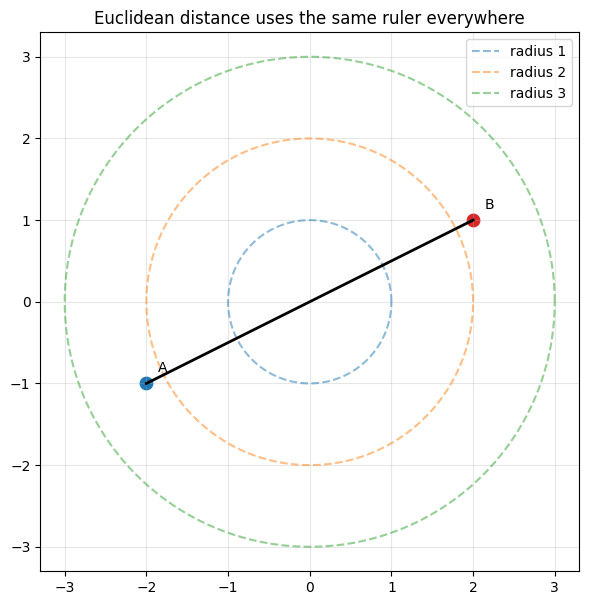

In [2]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([-2.0, -1.0])
B = np.array([2.0, 1.0])
distance = np.linalg.norm(A - B)
print(f"Euclidean distance between A and B: {distance:.3f}")

theta = np.linspace(0, 2 * np.pi, 400)
fig, ax = plt.subplots(figsize=(7, 7))
for r in [1, 2, 3]:
    ax.plot(r * np.cos(theta), r * np.sin(theta), linestyle='--', alpha=0.5, label=f"radius {r}")
ax.scatter(*A, color='tab:blue', s=80)
ax.scatter(*B, color='tab:red', s=80)
ax.plot([A[0], B[0]], [A[1], B[1]], color='black', linewidth=2)
ax.annotate('A', A, textcoords='offset points', xytext=(8, 8))
ax.annotate('B', B, textcoords='offset points', xytext=(8, 8))
ax.set_title('Euclidean distance uses the same ruler everywhere')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Interpretation

The picture says three things.

- Points at the same distance form circles.
- The shortest path is a straight line.
- The rule does not depend on location.

**Common misconception:** distance feels so natural that we forget it is already a geometric choice.

## 3. Vectors and matrices

In ML, a vector is best understood first as **an ordered list of numbers**.

- One token is usually represented by one vector.
- Several tokens together can be stacked into a matrix.

If a sentence has 3 tokens and each token is represented by 4 numbers, then the sentence can be written as a `3 x 4` matrix.

This matters because much of what an LLM does is ultimately built from **vector and matrix multiplication**.

In [3]:
import numpy as np

tokens = ["I", "like", "math"]
embeddings = np.array([
    [0.2, 0.1, 0.7, 0.3],
    [0.4, 0.6, 0.2, 0.8],
    [0.9, 0.3, 0.5, 0.4],
])

print("Tokens:", tokens)
print("\nEmbedding for one token = one vector")
print(embeddings[0])
print("Shape:", embeddings[0].shape)

print("\nSentence representation = a matrix")
print(embeddings)
print("Shape:", embeddings.shape)

W = np.array([
    [1.0, 0.2],
    [0.0, 1.0],
    [0.5, 0.5],
    [0.2, 0.8],
])
projected = embeddings @ W
print("\nMatrix multiplication example: embeddings @ W")
print(projected)
print("Projected shape:", projected.shape)

Tokens: ['I', 'like', 'math']

Embedding for one token = one vector
[0.2 0.1 0.7 0.3]
Shape: (4,)

Sentence representation = a matrix
[[0.2 0.1 0.7 0.3]
 [0.4 0.6 0.2 0.8]
 [0.9 0.3 0.5 0.4]]
Shape: (3, 4)

Matrix multiplication example: embeddings @ W
[[0.61 0.73]
 [0.66 1.42]
 [1.23 1.05]]
Projected shape: (3, 2)


### Interpretation

The output shows two key ideas.

- One token is a vector with shape `(4,)`.
- Three tokens stacked together form a matrix with shape `(3, 4)`.

And `embeddings @ W` is exactly the kind of linear algebra operation that appears everywhere in neural networks.

**One-line summary:** one token is a vector, a group of tokens becomes a matrix.

## 4. Tensors in ML

The word `tensor` can sound much more frightening than it needs to.

At the beginner level, it is enough to say this:

**In deep learning, a tensor is usually just a multi-dimensional array.**

- One number: scalar
- One list of numbers: vector
- One rectangular table of numbers: matrix
- More axes than that: tensor

If we process many sentences at once, we often get something shaped like `batch x tokens x features`.

**Common misconception:** in ML, the word tensor does not automatically mean we are doing full Riemannian tensor calculus.

In [4]:
import numpy as np

sentence_a = np.array([
    [0.2, 0.1, 0.7, 0.3],
    [0.4, 0.6, 0.2, 0.8],
    [0.9, 0.3, 0.5, 0.4],
])
sentence_b = np.array([
    [0.1, 0.8, 0.4, 0.2],
    [0.3, 0.5, 0.6, 0.1],
    [0.7, 0.2, 0.3, 0.9],
])

batch = np.stack([sentence_a, sentence_b], axis=0)
print("Tensor shape (batch, tokens, features):", batch.shape)
print("\nFirst sentence, second token:")
print(batch[0, 1])
print("\nSecond sentence matrix:")
print(batch[1])

Tensor shape (batch, tokens, features): (2, 3, 4)

First sentence, second token:
[0.4 0.6 0.2 0.8]

Second sentence matrix:
[[0.1 0.8 0.4 0.2]
 [0.3 0.5 0.6 0.1]
 [0.7 0.2 0.3 0.9]]


### Interpretation

The shape `(2, 3, 4)` means

- 2 sentences
- 3 tokens per sentence
- 4 features per token

**One-line summary:** a tensor is a convenient box that holds many vectors and matrices at once.

## 5. What embeddings are

An embedding turns a word or a sentence into **numerical coordinates**.

Why do we do that? Because computers are much better at numerical operations than at raw text.

The main intuition is this.

- Items used in similar contexts tend to be learned into similar regions of space.
- That makes “closeness” and “similarity” measurable.

The next example uses **handcrafted toy embeddings**, not real trained ones. That makes the geometry easier to see.

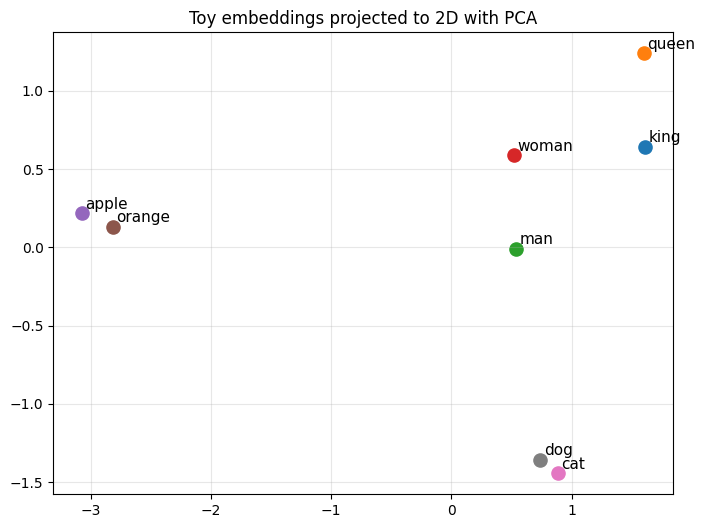

Analogy target scores:
 queen: 1.000
   dog: 0.437
   cat: 0.434
 apple: -0.375
orange: -0.383


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

toy_embeddings = {
    "king":  np.array([2.0,  1.0, 2.0, 0.2]),
    "queen": np.array([2.0, -1.0, 2.0, 0.2]),
    "man":   np.array([1.0,  1.0, 1.0, 0.1]),
    "woman": np.array([1.0, -1.0, 1.0, 0.1]),
    "apple": np.array([-2.0, 0.0, 0.2, 2.0]),
    "orange":np.array([-1.8, 0.1, 0.2, 1.8]),
    "cat":   np.array([0.2, 0.2, 1.4, -1.5]),
    "dog":   np.array([0.1, 0.3, 1.5, -1.3]),
}

words = list(toy_embeddings)
X = np.vstack([toy_embeddings[w] for w in words])
X2 = PCA(n_components=2).fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
for (x, y), word in zip(X2, words):
    ax.scatter(x, y, s=90)
    ax.text(x + 0.03, y + 0.03, word, fontsize=11)
ax.set_title('Toy embeddings projected to 2D with PCA')
ax.grid(alpha=0.3)
plt.show()

relation = toy_embeddings["king"] - toy_embeddings["man"] + toy_embeddings["woman"]

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

scores = {w: cosine(relation, v) for w, v in toy_embeddings.items() if w not in {"king", "man", "woman"}}
print("Analogy target scores:")
for word, score in sorted(scores.items(), key=lambda item: item[1], reverse=True):
    print(f"{word:>6}: {score:.3f}")

### Interpretation

In the PCA plot, similar categories were intentionally placed near one another.

The toy example is also designed so that `king - man + woman` lands near `queen`.

**Important warning:** this is useful intuition, but it is not a universal law. Real embeddings often show such patterns, yet not perfectly and not always.

## 6. Distance and similarity

To understand embeddings, we need to ask what it means for two vectors to be similar.

Three common answers are

- Euclidean distance: how far apart they are
- Dot product: how aligned they are, mixed with magnitude
- Cosine similarity: how similar their directions are

Cosine similarity is written as

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

So two vectors can have different lengths but still be very similar if they point in almost the same direction.

In [6]:
import numpy as np

x = np.array([3.0, 4.0])
y = np.array([6.0, 8.0])
z = np.array([4.0, 3.0])

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

pairs = {
    "x vs y": (x, y),
    "x vs z": (x, z),
}

for name, (a, b) in pairs.items():
    print(name)
    print("  Euclidean distance:", round(np.linalg.norm(a - b), 3))
    print("  Dot product:", round(float(np.dot(a, b)), 3))
    print("  Cosine similarity:", round(float(cosine(a, b)), 3))
    print()

x vs y
  Euclidean distance: 5.0
  Dot product: 50.0
  Cosine similarity: 1.0

x vs z
  Euclidean distance: 1.414
  Dot product: 24.0
  Cosine similarity: 0.96



### Interpretation

`x` and `y` point in exactly the same direction, so their cosine similarity is close to 1 even though their lengths differ.

`x` and `z` have similar sizes, but their directions are slightly different, so the cosine similarity is lower.

**One-line summary:** Euclidean distance answers “how far,” while cosine similarity answers “how aligned.”

## 7. Riemannian geometry intuition

Now we are ready for the core intuition.

**Riemannian geometry studies spaces where the distance rule can change from point to point.**

In Euclidean space, the ruler stays the same everywhere. On a curved or more general space, that need not be true.

A standard way to write this is

$$
ds^2 = g_{ij}(p)\,dx^i\,dx^j
$$

You do not need to memorize the notation right now. The main idea is simply that $g_{ij}(p)$ tells you how to measure tiny movements near the point $p$.

- Euclidean space: the rule is effectively fixed
- Riemannian space: the rule may depend on location or direction

That is why unit circles can turn into ellipses in the next picture.

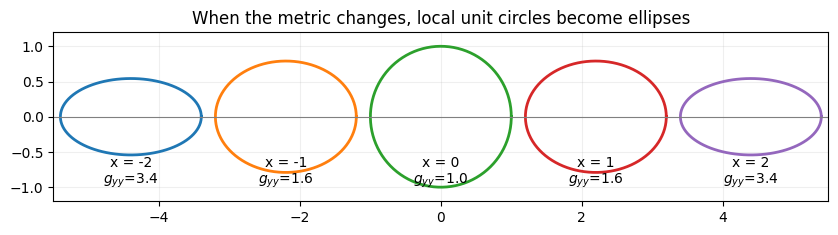

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def unit_ellipse_points(metric, n=200):
    eigenvalues, eigenvectors = np.linalg.eigh(metric)
    t = np.linspace(0, 2 * np.pi, n)
    unit_circle = np.stack([np.cos(t), np.sin(t)], axis=0)
    transform = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues))
    points = transform @ unit_circle
    return points[0], points[1]

positions = [-2, -1, 0, 1, 2]
fig, ax = plt.subplots(figsize=(10, 4))

for xpos in positions:
    metric = np.array([
        [1.0, 0.0],
        [0.0, 1.0 + 0.6 * xpos**2],
    ])
    ex, ey = unit_ellipse_points(metric)
    ax.plot(ex + xpos * 2.2, ey, linewidth=2)
    ax.text(xpos * 2.2, -0.95, f"x = {xpos}\n$g_{{yy}}$={metric[1,1]:.1f}", ha='center')

ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('When the metric changes, local unit circles become ellipses')
ax.set_aspect('equal')
ax.set_ylim(-1.2, 1.2)
ax.set_xlim(-5.5, 5.5)
ax.grid(alpha=0.2)
plt.show()

### Interpretation

In Euclidean space, the set of “length 1 directions” forms a circle. When the metric changes, that set can become an ellipse.

That means some directions are more expensive than others.

**Tangent-space intuition:** imagine touching a curved surface with a tiny flat sheet of paper. That tiny flat approximation is where the metric tells you how to measure length and angle locally.

## 8. What is related to LLMs, and what is not

This is the most important clarification in the notebook.

**Mainstream LLMs perform their actual computation mostly with linear algebra in Euclidean space.**

Their day-to-day work is built from things like

- vectors and matrices
- dot products and matrix multiplication
- functions such as softmax

So why mention Riemannian geometry at all?

Because it is usually a language for **interpretation**, not the engine itself.

- What the model computes: large-scale numerical operations in Euclidean space
- How we interpret embeddings: what notion of distance or geometry makes the learned structure easier to understand

**One-line summary:** Riemannian geometry is usually a lens for understanding embedding spaces, not the default engine that runs GPT-style models.

## 9. Attention as matrix computation

The core transformer formula is

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

At a beginner level, you can read the symbols like this.

- `Q`: what am I looking for?
- `K`: what clue does each token carry?
- `V`: what actual information will be mixed in?

The important point is that this is still built from familiar operations: **matrix multiplication plus softmax**.

Q =
 [[1.  0.2]
 [0.8 0.9]
 [1.3 1. ]]

K =
 [[0.9  0.1 ]
 [0.85 1.05]
 [1.3  1.1 ]]

V =
 [[1.  0. ]
 [0.5 1. ]
 [1.  1. ]]

Scaled attention scores =
 [[0.651 0.75  1.075]
 [0.573 1.149 1.435]
 [0.898 1.524 1.973]]

Attention weights =
 [[0.275 0.304 0.421]
 [0.194 0.346 0.46 ]
 [0.172 0.322 0.505]]

Context vectors =
 [[0.848 0.725]
 [0.827 0.806]
 [0.839 0.828]]


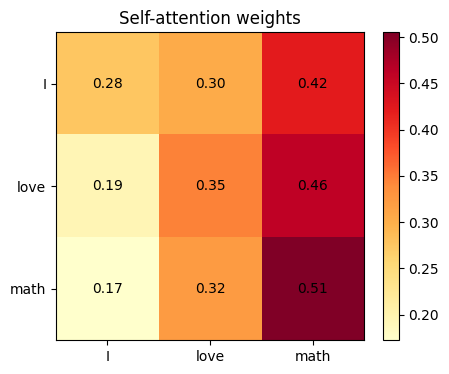

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

tokens = ["I", "love", "math"]
X = np.array([
    [1.0, 0.0],
    [0.5, 1.0],
    [1.0, 1.0],
])
W_Q = np.array([[1.0, 0.2], [0.3, 0.8]])
W_K = np.array([[0.9, 0.1], [0.4, 1.0]])
W_V = np.array([[1.0, 0.0], [0.0, 1.0]])

Q = X @ W_Q
K = X @ W_K
V = X @ W_V
scores = Q @ K.T / np.sqrt(K.shape[1])

def softmax(rows):
    shifted = rows - rows.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)

weights = softmax(scores)
context = weights @ V

print("Q =\n", Q)
print("\nK =\n", K)
print("\nV =\n", V)
print("\nScaled attention scores =\n", scores)
print("\nAttention weights =\n", weights)
print("\nContext vectors =\n", context)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights, cmap='YlOrRd')
ax.set_xticks(range(len(tokens)), tokens)
ax.set_yticks(range(len(tokens)), tokens)
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{weights[i, j]:.2f}", ha='center', va='center', color='black')
ax.set_title('Self-attention weights')
plt.colorbar(im, ax=ax)
plt.show()

### Interpretation

Each row of the attention-weight matrix tells us how much one token attends to the others.

Dividing by $\sqrt{d_k}$ helps prevent the scores from becoming too extreme before the softmax step.

**One-line summary:** attention is not magic. It is a way of turning vector relationships into weights, and then using those weights to mix information.

In [9]:
print("Optional section: if you want a real pretrained embedding demo in Jupyter, run:")
print("%pip install gensim")
print("Then execute the next cell. If you skip it, the rest of the notebook is still complete.")

Optional section: if you want a real pretrained embedding demo in Jupyter, run:
%pip install gensim
Then execute the next cell. If you skip it, the rest of the notebook is still complete.


In [10]:
try:
    import gensim.downloader as api
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    import numpy as np
except Exception as exc:
    print("Optional demo skipped:", exc)
else:
    words = ["king", "queen", "man", "woman", "apple", "orange"]
    try:
        model = api.load("glove-wiki-gigaword-50")
        vectors = np.vstack([model[w] for w in words])
        vectors_2d = PCA(n_components=2).fit_transform(vectors)

        fig, ax = plt.subplots(figsize=(7, 5))
        for (x, y), word in zip(vectors_2d, words):
            ax.scatter(x, y, s=90)
            ax.text(x + 0.02, y + 0.02, word, fontsize=11)
        ax.set_title("Optional pretrained embedding demo")
        ax.grid(alpha=0.3)
        plt.show()
    except Exception as exc:
        print("Optional demo could not run. This usually means no network access or no local cache.")
        print(exc)

Optional demo skipped: No module named 'gensim'


## 10. Optional exercise: a pretrained embedding demo

So far we have used fully self-contained examples.

The next cells are optional.

- Run them only if `gensim` is available.
- If there is no network access or no local cache, you can skip them.
- The notebook remains complete without this section.